
# Experiment: Cross-Experiment Error Analysis Deep Dive

Objective:
- Go beyond the first-pass failure labels and ask what *kind* of wrong answers the models produce across experiments.
- Separate subtle, target-language near-misses from harder failures like source copying, script failure, decoding collapse, and English task escape.
- Quantify how those families move with difficulty (`depth`, grammar size, agreement condition, target orthography) and show concrete examples of each.

Success criteria:
- A compact taxonomy that explains most wrong outputs.
- At least one figure that shows cross-experiment error-family shifts.
- Conditioned slices for `agreement` and `orthography`, plus representative examples.


In [1]:
from __future__ import annotations

import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from IPython.display import Markdown, display
from wordfreq import zipf_frequency

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.precision", 3)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".project-root").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root via .project-root")


PROJECT_ROOT = find_project_root(Path.cwd())
CACHE_DIR = PROJECT_ROOT / "notebooks" / "cache" / "error-analysis"
DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import aesthetics as aes
from aesthetics import (
    PAPER_WIDTH_IN,
    FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN,
)

FIGSIZE_STACKED = (aes.COLM_PAPER_WIDTH_IN, 2.2 * FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN)
FIGSIZE_HEATMAP = (aes.COLM_PAPER_WIDTH_IN, 1.5 * FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN)
FIGSIZE_TWO_PANEL = (aes.COLM_PAPER_WIDTH_IN, 1.4 * FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN)
FIGSIZE_THREE_PANEL = (aes.COLM_PAPER_WIDTH_IN, 1.45 * FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN)
FIG_SIZE_SINGLE = (aes.COLM_PAPER_WIDTH_IN, aes.FIG_HEIGHT_SINGLEROW_IN)

WORD_ORDER_EXP = "wordorder_large_exp"
ORTHOGRAPHY_EXP = "orthography_exp"
WORD_ORDER_DATASETS = ("wordorder_exp", "wordorder_large_exp")
ORTHOGRAPHY_DATASETS = ("orthography_exp", "orthography_large_exp")

if WORD_ORDER_EXP not in WORD_ORDER_DATASETS:
    raise ValueError(f"WORD_ORDER_EXP must be one of {WORD_ORDER_DATASETS}, got {WORD_ORDER_EXP!r}")
if ORTHOGRAPHY_EXP not in ORTHOGRAPHY_DATASETS:
    raise ValueError(
        f"ORTHOGRAPHY_EXP must be one of {ORTHOGRAPHY_DATASETS}, got {ORTHOGRAPHY_EXP!r}"
    )

EXPERIMENT_ORDER = ["wordorder", "size", "agreement", "orthography"]
MODEL_ORDER = ["gpt-5", "gpt-5-mini", "gpt-5-nano"]
FAMILY_ORDER = [
    "pure_reordering",
    "licensed_near_miss",
    "truncation_or_omission",
    "source_leakage",
    "script_or_form",
    "unlicensed_or_hallucinated",
    "task_escape",
    "degeneration",
    "other",
]
FAMILY_PALETTE = {
    "pure_reordering": "#5B8FF9",
    "licensed_near_miss": "#2A9D8F",
    "truncation_or_omission": "#F4A261",
    "source_leakage": "#E76F51",
    "script_or_form": "#8AB17D",
    "task_escape": "#7A3B69",
    "degeneration": "#6C757D",
    "unlicensed_or_hallucinated": "#B08968",
    "other": "#CED4DA",
}
FAMILY_LABELS = {
    "pure_reordering": "word ordering",
    "licensed_near_miss": "recall error",
    "truncation_or_omission": "omission",
    "source_leakage": "source vocab",
    "script_or_form": "orthography",
    "task_escape": "task escape",
    "degeneration": "degeneration",
    "unlicensed_or_hallucinated": "hallucinated vocab",
    "other": "other",
}
FAMILY_PALETTE_LABELS = {
    FAMILY_LABELS[family]: color for family, color in FAMILY_PALETTE.items()
}
META_RE = re.compile(
    r"\b(?:translate|translation|cannot|cant|can not|unable|sorry|input|source|sentence|grammar|scfg|exact|determine|provided|given|lexical|token|unknown|parse|information|reliably|hand)\b",
    re.IGNORECASE,
)
LATIN_WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")
ENGLISH_ZIPF_MIN = 3.5


def tokenize(text: str | float | None) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    return text.split()


def normalized_alpha_tokens(text: str | float | None) -> list[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    return [token.lower() for token in LATIN_WORD_RE.findall(text)]


def normalize_vocab_tokens(vocab: set[str] | None) -> set[str]:
    normalized: set[str] = set()
    for token in vocab or set():
        normalized.update(normalized_alpha_tokens(str(token)))
    return normalized


def build_english_lookup(
    token_lists: pd.Series, min_zipf: float = ENGLISH_ZIPF_MIN
) -> dict[str, bool]:
    unique_tokens = sorted(
        {token for tokens in token_lists for token in tokens if len(token) >= 2}
    )
    return {token: zipf_frequency(token, "en") >= min_zipf for token in unique_tokens}


def english_word_tokens(
    pred_alpha_tokens: list[str],
    target_vocab_alpha: set[str],
    english_lookup: dict[str, bool],
) -> list[str]:
    return [
        token
        for token in dict.fromkeys(pred_alpha_tokens)
        if english_lookup.get(token, False) and token not in target_vocab_alpha
    ]


def counter_overlap(left: list[str], right: list[str]) -> int:
    return sum((Counter(left) & Counter(right)).values())


def side_b_vocab(grammar: dict) -> set[str]:
    tokens: list[str] = []
    for key in [
        "verbs",
        "nouns",
        "propns",
        "prons",
        "adjs",
        "det_def",
        "det_indef",
        "comps",
    ]:
        tokens.extend(grammar["b"].get(key, []))
    for key in [
        "verb_paradigms",
        "noun_paradigms",
        "propn_paradigms",
        "pronoun_paradigms",
    ]:
        for item in grammar["b"].get(key, []):
            if not isinstance(item, dict):
                continue
            tokens.extend(str(item.get("lemma", "")).split())
            tokens.extend(str(item.get("form", "")).split())
            if "forms" in item:
                for form in item["forms"].values():
                    tokens.extend(str(form).split())
    vocab: set[str] = set()
    for token in tokens:
        vocab.update(str(token).split())
    return vocab


def build_vocab_map() -> dict[str, set[str]]:
    vocab_map: dict[str, set[str]] = {}
    for exp_dir in [
        "wordorder_exp",
        "wordorder_large_exp",
        "size_exp",
        "orthography_exp",
        "orthography_large_exp",
        "agreement_exp",
    ]:
        for path in sorted((DATA_DIR / exp_dir).glob("grammar_*.json")):
            grammar_name = path.stem.split("grammar_")[1]
            vocab_map[grammar_name] = side_b_vocab(json.loads(path.read_text()))
    return vocab_map


def classify_error_family(row: pd.Series) -> str:
    pred_tokens = row["pred_tokens"]
    ref_tokens = row["ref_tokens"]
    vocab = row["target_vocab"] if isinstance(row["target_vocab"], set) else set()
    pred_len = len(pred_tokens)
    ref_len = len(ref_tokens)

    if row["exact_match"]:
        return "exact"
    if row["failure_mode"] == "word_order_only":
        return "pure_reordering"
    if row["failure_mode"] in {"wrong_script", "diacritic_drop"}:
        return "script_or_form"
    if row["meta_response"]:
        return "task_escape"
    if (
        row["failure_mode"] in {"copied_source", "source_lexicon_intrusion"}
        or row["source_share"] >= 0.5
    ):
        return "source_leakage"
    if row["failure_mode"] == "repetition_loop":
        return "degeneration"
    if row["failure_mode"] in {"partial_span", "too_short"}:
        return "truncation_or_omission"
    if (
        pred_len < ref_len
        and row["target_precision"] >= 0.8
        and row["target_recall"] < 0.8
    ):
        return "truncation_or_omission"
    if (
        pred_len
        and vocab
        and row["licensed_token_share"] >= 0.8
        and row["target_recall"] >= 0.5
    ):
        return "licensed_near_miss"
    if pred_len and vocab and row["licensed_token_share"] < 0.8:
        return "unlicensed_or_hallucinated"
    return "other"


def family_share(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    counts = df.groupby(group_cols, observed=False).size().rename("count").reset_index()
    totals = (
        df.groupby(group_cols[:-1], observed=False).size().rename("total").reset_index()
    )
    merged = counts.merge(totals, on=group_cols[:-1], how="left")
    merged["share"] = merged["count"] / merged["total"]
    return merged


def pct(value: float) -> str:
    return f"{100 * value:.1f}%"


def family_label(family: str) -> str:
    return FAMILY_LABELS.get(family, family.replace("_", " "))


def family_label_list(families: list[str]) -> list[str]:
    return [family_label(family) for family in families]


vocab_map = build_vocab_map()
target_vocab_alpha_map = {
    grammar_name: normalize_vocab_tokens(vocab)
    for grammar_name, vocab in vocab_map.items()
}
rows_df = pd.read_csv(CACHE_DIR / "rows.csv")
if "dataset" not in rows_df.columns:
    rows_df["dataset"] = rows_df["exp"].map(
        {
            "wordorder": "wordorder_exp",
            "size": "size_exp",
            "agreement": "agreement_exp",
            "orthography": "orthography_exp",
        }
    ).fillna("unknown")

cached_dataset_counts = (
    rows_df.groupby(["dataset", "exp"], observed=False).size().rename("rows").reset_index()
)
rows_df = rows_df.loc[
    ((rows_df["exp"].astype(str) != "wordorder") | rows_df["dataset"].eq(WORD_ORDER_EXP))
    & ((rows_df["exp"].astype(str) != "orthography") | rows_df["dataset"].eq(ORTHOGRAPHY_EXP))
].copy()

rows_df["model_name"] = rows_df["fuzzy_model"]
rows_df["exp"] = pd.Categorical(
    rows_df["exp"], categories=EXPERIMENT_ORDER, ordered=True
)
rows_df["fuzzy_model"] = pd.Categorical(
    rows_df["fuzzy_model"], categories=MODEL_ORDER, ordered=True
)
rows_df["pred_tokens"] = rows_df["model_answer"].fillna("").map(tokenize)
rows_df["ref_tokens"] = rows_df["output_sentence"].fillna("").map(tokenize)
rows_df["src_tokens"] = rows_df["input_sentence"].fillna("").map(tokenize)
rows_df["pred_alpha_tokens"] = (
    rows_df["model_answer"].fillna("").map(normalized_alpha_tokens)
)
rows_df["target_vocab"] = rows_df["grammar_name"].map(vocab_map)
rows_df["target_vocab_alpha"] = rows_df["grammar_name"].map(target_vocab_alpha_map)
english_lookup = build_english_lookup(rows_df["pred_alpha_tokens"])
rows_df["english_word_tokens"] = rows_df.apply(
    lambda row: english_word_tokens(
        row["pred_alpha_tokens"],
        row["target_vocab_alpha"]
        if isinstance(row["target_vocab_alpha"], set)
        else set(),
        english_lookup,
    ),
    axis=1,
)
rows_df["contains_english_words"] = rows_df["english_word_tokens"].map(bool)
rows_df["english_word_count"] = rows_df["english_word_tokens"].map(len)
rows_df["target_recall"] = rows_df.apply(
    lambda row: 0.0
    if not row["ref_tokens"]
    else counter_overlap(row["pred_tokens"], row["ref_tokens"])
    / len(row["ref_tokens"]),
    axis=1,
)
rows_df["target_precision"] = rows_df.apply(
    lambda row: 0.0
    if not row["pred_tokens"]
    else counter_overlap(row["pred_tokens"], row["ref_tokens"])
    / len(row["pred_tokens"]),
    axis=1,
)
rows_df["source_share"] = rows_df.apply(
    lambda row: 0.0
    if not row["pred_tokens"]
    else counter_overlap(row["pred_tokens"], row["src_tokens"])
    / len(row["pred_tokens"]),
    axis=1,
)
rows_df["licensed_token_share"] = rows_df.apply(
    lambda row: 0.0
    if not row["pred_tokens"]
    else sum(
        token
        in (row["target_vocab"] if isinstance(row["target_vocab"], set) else set())
        for token in row["pred_tokens"]
    )
    / len(row["pred_tokens"]),
    axis=1,
)
rows_df["fully_licensed"] = rows_df["licensed_token_share"].eq(1.0)
rows_df["same_len"] = rows_df["pred_len"] == rows_df["ref_len"]
rows_df["meta_response"] = rows_df["model_answer"].fillna("").str.contains(META_RE)
rows_df["error_family"] = rows_df.apply(classify_error_family, axis=1)
wrong_df = rows_df.loc[~rows_df["exact_match"]].copy()
size_order = [
    f"{int(value):,}"
    for value in sorted(
        rows_df.loc[rows_df["exp"] == "size", "n_words"].dropna().unique()
    )
]
rows_df["size_bin"] = pd.Categorical(
    rows_df["n_words"].map(
        lambda value: f"{int(value):,}" if pd.notna(value) else np.nan
    ),
    categories=size_order,
    ordered=True,
)
wrong_df["size_bin"] = rows_df.loc[wrong_df.index, "size_bin"]

print(f"Using WORD_ORDER_EXP={WORD_ORDER_EXP}")
print(f"Using ORTHOGRAPHY_EXP={ORTHOGRAPHY_EXP}")
print(f"Loaded {len(rows_df):,} rows and {len(wrong_df):,} wrong answers after dataset filtering.")
print(
    "Error families:",
    ", ".join(
        family for family in FAMILY_ORDER if family in set(wrong_df["error_family"])
    ),
)
print(
    "Wrong answers with English lexical intrusion:",
    pct(wrong_df["contains_english_words"].mean()),
)
selected_counts = cached_dataset_counts.loc[
    cached_dataset_counts["dataset"].isin([
        WORD_ORDER_EXP,
        ORTHOGRAPHY_EXP,
        "size_exp",
        "agreement_exp",
    ])
].copy()
print(selected_counts.sort_values(["exp", "dataset"]).to_string(index=False))

/var/folders/70/m9xv6w4j3bl15rm0jsz76ltm0000gn/T/ipykernel_65978/3515321363.py:267: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  rows_df = pd.read_csv(CACHE_DIR / "rows.csv")


Using WORD_ORDER_EXP=wordorder_large_exp
Using ORTHOGRAPHY_EXP=orthography_exp
Loaded 39,360 rows and 21,741 wrong answers after dataset filtering.
Error families: pure_reordering, licensed_near_miss, truncation_or_omission, source_leakage, script_or_form, unlicensed_or_hallucinated, task_escape, degeneration, other
Wrong answers with English lexical intrusion: 10.1%
            dataset         exp  rows
      agreement_exp   agreement 20160
    orthography_exp orthography   720
           size_exp        size  5040
wordorder_large_exp   wordorder 13440



## Plan

Hypotheses:
- Many rows that look like `hallucinated_vocab` in the first pass are actually *recall errors*: the model stays inside the target lexicon but retrieves the wrong lexical item or inflection.
- Weak-model failures on harder grammars should shift from subtle adequacy issues toward source leakage and explicit English task escape.
- `orthography` should isolate form/script problems from the rest of the translation pipeline.

Metrics used here:
- `target_recall` / `target_precision`: multiset token overlap with the reference.
- `source_share`: how much of the prediction is copied from the source sentence.
- `licensed_token_share`: how much of the prediction stays inside the grammar's target-side vocabulary.
- `meta_response`: whether the model answers in English about the task instead of translating.


Dataset selectors:
- `WORD_ORDER_EXP` and `ORTHOGRAPHY_EXP` at the top of the setup cell choose which cached dataset backs the `wordorder` and `orthography` analyses.


## A Compact Error Taxonomy

The first-pass labels are useful, but they over-separate some patterns and under-separate others. The family view below answers a more causal question: when the model is wrong, is it still behaving like a translator, or has it switched into some other failure mode?

Alongside the mutually exclusive taxonomy, I also track one overlapping diagnostic: **English lexical intrusion**. This fires when the model's final answer contains common English words that are *not* licensed by that grammar's target vocabulary, so accidental homographs in the target lexicon do not count.

In [2]:
family_share_df = family_share(wrong_df, ["exp", "fuzzy_model", "error_family"])
dominant_family_df = (
    family_share_df.sort_values(
        ["exp", "fuzzy_model", "share"], ascending=[True, True, False]
    )
    .groupby(["exp", "fuzzy_model"], as_index=False, observed=False)
    .head(1)
    .rename(
        columns={
            "error_family": "dominant_wrong_family",
            "share": "dominant_wrong_share",
        }
    )
)

task_escape_df = family_share_df.loc[
    family_share_df["error_family"] == "task_escape", ["exp", "fuzzy_model", "share"]
].rename(columns={"share": "task_escape_within_wrong"})

english_intrusion_df = (
    wrong_df.groupby(["exp", "fuzzy_model"], observed=False)["contains_english_words"]
    .mean()
    .reset_index(name="english_words_within_wrong")
)

topline_df = (
    rows_df.groupby(["exp", "fuzzy_model"], observed=False)
    .agg(
        rows=("custom_id", "size"),
        exact_match=("exact_match", "mean"),
        bow_match=("bow_match", "mean"),
        mean_ref_len=("ref_len", "mean"),
    )
    .reset_index()
    .merge(dominant_family_df, on=["exp", "fuzzy_model"], how="left")
    .merge(task_escape_df, on=["exp", "fuzzy_model"], how="left")
    .merge(english_intrusion_df, on=["exp", "fuzzy_model"], how="left")
    .fillna({"task_escape_within_wrong": 0.0, "english_words_within_wrong": 0.0})
)

display(
    topline_df.assign(
        exact_match=lambda df: (100 * df["exact_match"]).round(1),
        bow_match=lambda df: (100 * df["bow_match"]).round(1),
        dominant_wrong_family=lambda df: df["dominant_wrong_family"].map(family_label),
        dominant_wrong_share=lambda df: (100 * df["dominant_wrong_share"]).round(1),
        task_escape_within_wrong=lambda df: (
            100 * df["task_escape_within_wrong"]
        ).round(1),
        english_words_within_wrong=lambda df: (
            100 * df["english_words_within_wrong"]
        ).round(1),
        mean_ref_len=lambda df: df["mean_ref_len"].round(1),
    )[
        [
            "exp",
            "fuzzy_model",
            "rows",
            "exact_match",
            "bow_match",
            "dominant_wrong_family",
            "dominant_wrong_share",
            "task_escape_within_wrong",
            "english_words_within_wrong",
            "mean_ref_len",
        ]
    ].sort_values(["exp", "fuzzy_model"])
)

,exp,fuzzy_model,rows,exact_match,bow_match,dominant_wrong_family,dominant_wrong_share,task_escape_within_wrong,english_words_within_wrong,mean_ref_len
0,wordorder,gpt-5,5040,69.2,69.8,recall error,81.8,0.3,1.6,16.2
1,wordorder,gpt-5-mini,5040,52.3,53.9,recall error,54.4,0.1,4.5,16.2
2,wordorder,gpt-5-nano,3360,18.4,34.3,task escape,23.6,23.6,27.5,16.2
3,size,gpt-5,1680,82.1,86.2,recall error,68.3,0.3,3.3,16.1
4,size,gpt-5-mini,1680,50.7,55.2,recall error,33.7,0.4,8.3,16.1
5,size,gpt-5-nano,1680,1.7,32.1,word ordering,30.9,24.0,28.1,16.1
6,agreement,gpt-5,6720,47.3,47.3,recall error,86.4,0.0,3.8,15.3
7,agreement,gpt-5-mini,6720,46.9,46.9,recall error,87.5,0.0,4.4,15.3
8,agreement,gpt-5-nano,6720,32.3,32.3,recall error,78.0,2.4,4.9,15.3
9,orthography,gpt-5,360,33.3,37.2,hallucinated vocab,38.3,0.8,3.8,17.0


In [3]:
taxonomy_descriptions = {
    "pure_reordering": "All of the right target tokens are present, but the sequence order is wrong.",
    "licensed_near_miss": "The model stays mostly inside the target lexicon and overlaps heavily with the reference, but recalls the wrong lexical item or form.",
    "truncation_or_omission": "The output is mostly target-side material, but it drops a span or stops too early.",
    "source_leakage": "Source-language words leak into the answer, or the source is copied outright.",
    "script_or_form": "The lexical mapping may be close, but the orthography, diacritics, or surface realization is wrong.",
    "task_escape": "The model stops translating and answers in English about the task or its uncertainty.",
    "degeneration": "The decoder falls into repetition or a locally collapsed pattern.",
    "unlicensed_or_hallucinated": "The prediction introduces tokens that are not licensed by the grammar's target vocabulary.",
    "other": "Residual target-like errors that do not fit the cleaner families above.",
}

taxonomy_order = [
    family for family in FAMILY_ORDER if family in set(wrong_df["error_family"])
]
taxonomy_rows = []
for family in taxonomy_order:
    example = (
        wrong_df.loc[wrong_df["error_family"] == family]
        .sort_values(
            [
                "target_recall",
                "licensed_token_share",
                "source_share",
                "exp",
                "model_name",
                "depth",
                "n_words",
            ],
            ascending=[False, False, True, True, True, True, True],
            na_position="last",
        )
        .head(1)
    )
    if example.empty:
        continue
    row = example.iloc[0]
    taxonomy_rows.append(
        {
            "error_family": family,
            "description": taxonomy_descriptions[family],
            "exp": row["exp"],
            "model": row["model_name"],
            "failure_mode": row["failure_mode"],
            "input_sentence": row["input_sentence"],
            "output_sentence": row["output_sentence"],
            "model_answer": row["model_answer"],
        }
    )

glossary_sections = ["### Taxonomy Glossary: descriptions plus one example per family"]
for item in taxonomy_rows:
    glossary_sections.extend(
        [
            f"#### `{family_label(item['error_family'])}`",
            item["description"],
            "",
            f"Example: `{item['exp']}` | `{item['model']}` | `{item['failure_mode']}`",
            f"- Input: `{item['input_sentence']}`",
            f"- Target: `{item['output_sentence']}`",
            f"- Prediction: `{item['model_answer']}`",
            "",
        ]
    )

display(Markdown("\n".join(glossary_sections)))

### Taxonomy Glossary: descriptions plus one example per family
#### `word ordering`
All of the right target tokens are present, but the sequence order is wrong.

Example: `wordorder` | `gpt-5` | `word_order_only`
- Input: `daj spurizob tahlofsix daj evkexiy`
- Target: `bicbkiwboqfam kborvpon sbonzik bicbkiwboqfam dgabgul`
- Prediction: `bicbkiwboqfam dgabgul sbonzik bicbkiwboqfam kborvpon`

#### `recall error`
The model stays mostly inside the target lexicon and overlaps heavily with the reference, but recalls the wrong lexical item or form.

Example: `wordorder` | `gpt-5` | `hallucinated_vocab`
- Input: `tehempal zuvgiz zsuqnem plid aw gocptabad uwsostug diron bixot ov gnef buq`
- Target: `zih dsahov dpeyob kuh knohoh um vixun aj dsuy sfaqifstub`
- Prediction: `zih dsahov dpeyob kuh fpam knohoh um vixun aj dsuy sfaqifstub`

#### `omission`
The output is mostly target-side material, but it drops a span or stops too early.

Example: `agreement` | `gpt-5` | `partial_span`
- Input: `hek kilyay zayxuk balfer gegbeq ton wez cirjodyon gegbeq lovsex jejcesfiqzip gegbeq piztolsat lejyon gegbeq xadnon ricfodkokwehyon gegbeq wul xugquh ton yiq`
- Target: `tavseg dezcuy bagmaydiq sac nivcih ciw midnet ten han jildey ciw midnet jiwyox qosmul ciw midnet reb somdey ciw midnet gaxlomrok heznuwdey ciw midnet xaypoczuk yujyendug ten pulrupwax`
- Prediction: `dezcuy bagmaydiq sac nivcih ciw midnet ten han jildey ciw midnet jiwyox qosmul ciw midnet reb somdey ciw midnet gaxlomrok heznuwdey ciw midnet xaypoczuk yujyendug ten pulrupwax`

#### `source vocab`
Source-language words leak into the answer, or the source is copied outright.

Example: `wordorder` | `gpt-5-nano` | `too_long`
- Input: `pkubeq gvow ofuqdpuddfit kac szem as nuv`
- Target: `ofbgas ut uztfax tsef nkayuqzum`
- Prediction: `iv tsef ofbgas ut kac szem as nuv`

#### `orthography`
The lexical mapping may be close, but the orthography, diacritics, or surface realization is wrong.

Example: `orthography` | `gpt-5` | `diacritic_drop`
- Input: `viyreylej qokyumjur pitkinnas`
- Target: `תִכ שאװ יאהנאפפױר מעטדיב קאװּאתכיּ`
- Prediction: `תכ שאװ יאהנאפפױר מעטדיב קאװאתכי`

#### `hallucinated vocab`
The prediction introduces tokens that are not licensed by the grammar's target vocabulary.

Example: `agreement` | `gpt-5-mini` | `mixed_other`
- Input: `laz fok xek tok hes pewbuf diqlog qom tuhpax kan diqlog moz tok rut yej`
- Target: `xaw rahxop nuwkan mebgac siknus yoqsofpis mebbij yaqgaf rahxop nig`
- Prediction: `laz fok xek rahxop nuwkan mebgac siknus yoqsofpis mebbij yaqgaf rahxop nig`

#### `task escape`
The model stops translating and answers in English about the task or its uncertainty.

Example: `agreement` | `gpt-5-nano` | `same_length_substitution`
- Input: `tesgimvublal fuyfilsitkeqyen vihqis tay gavxok zozmet zupjof lafxobxar vihqis xunmocjuv vunxar zozmet budfaymahbur jat qopyopkihgid fuyfilsitkeqyen vihqis tupreg fav zurxar budfaymahbur ditziyzeryow`
- Target: `gigmecvot xuj bup tikperpolsov vixmajbur tab mow wah duyzoj folbetqos tikperpolsov gow kajnor toypirdis mow wah zayrukqammew vixfizrij jodfis xuj bup tikperpolsov teljob nax zayrukqammew zeq`
- Prediction: `teljob xuj bup tikperpolsov vixmajbur tab mow wah duyzoj folbetqos tikperpolsov gow kajnor toypirdis mow wah unknown vixfizrij jodfis xuj bup tikperpolsov teljob nax unknown zeq`

#### `degeneration`
The decoder falls into repetition or a locally collapsed pattern.

Example: `agreement` | `gpt-5-nano` | `repetition_loop`
- Input: `saj xenveljadjuy poyxof`
- Target: `galmiv ducviqgac jibril`
- Prediction: `galmiv jibril ducviqgac jibril`

#### `other`
Residual target-like errors that do not fit the cleaner families above.

Example: `agreement` | `gpt-5-nano` | `mixed_other`
- Input: `babnewpeg yuxjijlisqos yukbot vepged ged babnewpeg juh nincep bib ged muy web ged zaf qiq sut finqop verdac poqreb ged yutfam jirxoydukwel sim nuvgiq babnewpeg kab herwud`
- Target: `jacsag sed pokrej giq bir yungim jacsag fac yesmiyyiy seskafporsuz quy colduq bir yungim hirnes vit goyzafxic bir yungim jivvog cak kuzdaljiy tig hut likyuz bar bir yungim yaf vekpiyqapjuj cutkeqfarcem dol jacsag romxonyamcey wabpegjox`
- Prediction: `jacsag sed pokrej giq jacsag yipvuz seskafporsuz quy colduq wabnix huv jon yavqun cak kuzdaljiy dol likyuz bar yaf vekpiyqapjuj ciq rex dol jacsag muz wabpegjox`


(PosixPath('/Users/jacksonpetty/Development/llm-scfg/notebooks/figures/error_taxonomy.pdf'),
 PosixPath('/Users/jacksonpetty/Development/llm-scfg/notebooks/figures/error_taxonomy.png'))

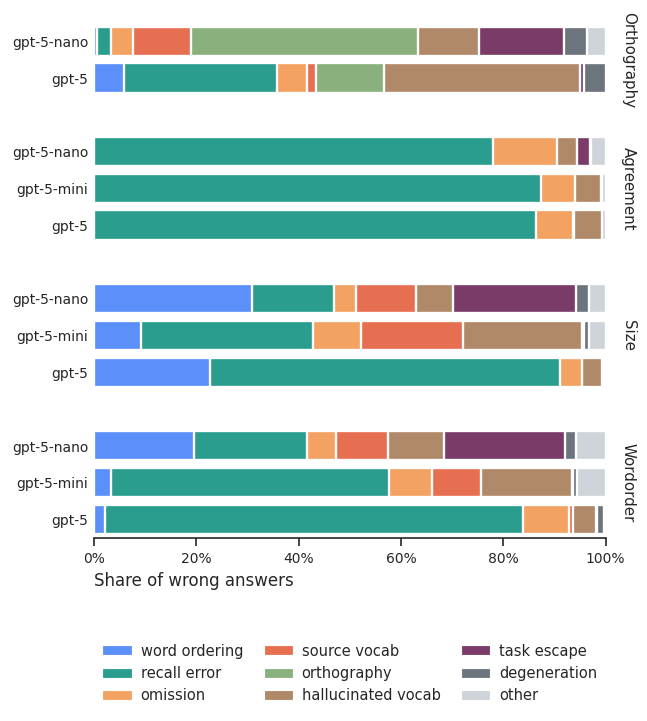

In [4]:
plot_df = family_share_df.copy()
present_families = [
    family for family in FAMILY_ORDER if family in set(plot_df["error_family"])
]
plot_df["error_family"] = pd.Categorical(
    plot_df["error_family"], categories=present_families, ordered=True
)

row_order = []
row_label_map = {}
for exp in EXPERIMENT_ORDER:
    exp_rows = []
    for model in MODEL_ORDER:
        has_rows = (
            (wrong_df["exp"].astype(str) == exp)
            & (wrong_df["fuzzy_model"].astype(str) == model)
        ).any()
        if has_rows:
            row_key = f"{exp}::{model}"
            row_order.append(row_key)
            row_label_map[row_key] = model
            exp_rows.append(row_key)
    if exp_rows:
        gap_key = f"gap::{exp}"
        row_order.append(gap_key)
        row_label_map[gap_key] = ""

if row_order and row_order[-1].startswith("gap::"):
    row_order = row_order[:-1]

plot_df["row"] = plot_df["exp"].astype(str) + "::" + plot_df["fuzzy_model"].astype(str)
plot_df["row"] = pd.Categorical(plot_df["row"], categories=row_order, ordered=True)
plot_df = plot_df.sort_values(["row", "error_family"])

group_centers = {}
for exp in EXPERIMENT_ORDER:
    exp_positions = [
        row_order.index(f"{exp}::{model}")
        for model in MODEL_ORDER
        if f"{exp}::{model}" in row_order
    ]
    if exp_positions:
        group_centers[exp] = float(np.mean(exp_positions))

fig, ax = plt.subplots(figsize=FIGSIZE_STACKED)
(
    so.Plot(plot_df, x="share", y="row", color="error_family")
    .scale(
        color=so.Nominal(values=FAMILY_PALETTE, order=present_families),
        y=so.Nominal(order=row_order),
    )
    .add(so.Bar(edgecolor="white", edgewidth=0.7, alpha=1), so.Stack())
    .on(ax)
    .plot()
)

ax.set_xlim(0, 1)
ax.set_yticks(range(len(row_order)))
ax.set_yticklabels([row_label_map[key] for key in row_order])
ax.invert_yaxis()
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Share of wrong answers")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(aes.PCT_FORMATTER)

for legend in fig.legends:
    legend.set_visible(False)

for exp, center in group_centers.items():
    ax.text(
        1.03,
        center,
        exp.title(),
        # transform=ax.get_yaxis_transform(),
        ha="left",
        va="center",
        rotation=270,
        fontsize=9,
    )

# for idx, row_key in enumerate(row_order):
#     if row_key.startswith("gap::"):
#         pass
#         # ax.axhline(idx - 0.5, color="0.85", linewidth=1)

legend_families = present_families
legend_handles = [
    plt.Rectangle(
        (0, 0), 1, 1, facecolor=FAMILY_PALETTE[family], edgecolor="white", linewidth=0.7
    )
    for family in legend_families
]
legend_labels = family_label_list(legend_families)
ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    columnspacing=1.4,
    handletextpad=0.6,
    frameon=False,
)
sns.despine(left=True)
plt.tight_layout()

aes.save_figure("error_taxonomy")



Two immediate takeaways:
- `agreement` is mostly not a hallucination problem. Even when the models fail, they often stay inside the target lexicon and produce structurally plausible target sentences.
- The weakest models on `wordorder`, `size`, and `orthography` frequently stop acting like translators at all: source vocab and English task escape become major mass.


,target recall,target precision,source share,licensed share,meta response,english words
error_family,,,,,,
word ordering,100.0,100.0,0.1,100.0,0.0,0.0
recall error,84.1,85.1,4.6,95.8,0.0,2.9
omission,67.3,87.2,3.6,95.0,0.0,1.3
source vocab,24.0,23.8,72.0,37.9,0.0,17.0
orthography,2.7,2.7,0.6,2.7,80.7,83.3
hallucinated vocab,54.2,55.2,27.4,65.7,0.0,11.5
task escape,1.1,1.1,1.2,3.2,100.0,100.0
degeneration,31.3,62.1,2.4,87.3,0.0,2.1
other,31.5,39.5,6.2,80.1,0.0,2.1


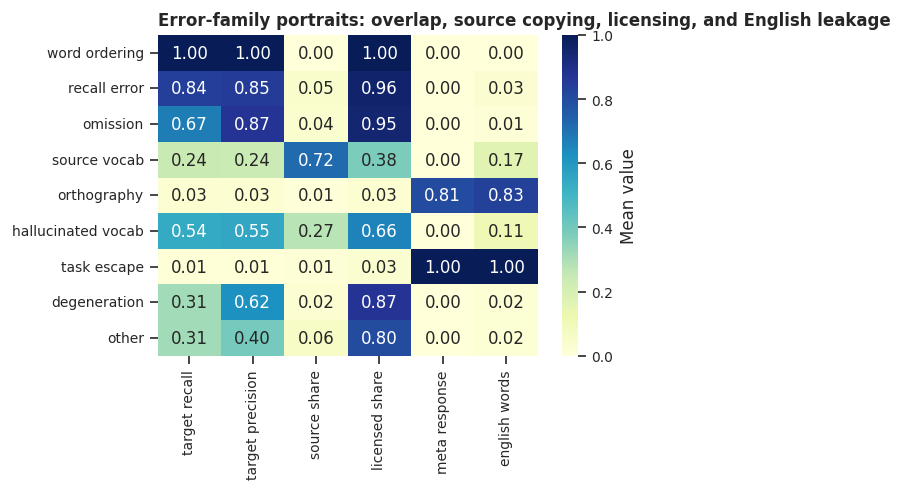

In [5]:
portrait_df = (
    wrong_df.groupby("error_family", observed=False)
    .agg(
        target_recall=("target_recall", "mean"),
        target_precision=("target_precision", "mean"),
        source_share=("source_share", "mean"),
        licensed_token_share=("licensed_token_share", "mean"),
        meta_response=("meta_response", "mean"),
        contains_english_words=("contains_english_words", "mean"),
    )
    .reindex(
        [family for family in FAMILY_ORDER if family in set(wrong_df["error_family"])]
    )
)

metric_labels = {
    "target_recall": "target recall",
    "target_precision": "target precision",
    "source_share": "source share",
    "licensed_token_share": "licensed share",
    "meta_response": "meta response",
    "contains_english_words": "english words",
}
portrait_display_df = (100 * portrait_df).round(1).rename(columns=metric_labels)
portrait_display_df.index = portrait_display_df.index.map(family_label)

display(portrait_display_df)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)
portrait_heatmap_df = portrait_df.rename(index=FAMILY_LABELS, columns=metric_labels)
sns.heatmap(
    portrait_heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Mean value"},
    ax=ax,
)
ax.set_title(
    "Error-family portraits: overlap, source copying, licensing, and English leakage"
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Difficulty Gradients

The next question is not just *what* the error families are, but *when* they appear. The plots below separate two different failure trajectories:
- a graceful degradation trajectory, where predictions remain target-like but drift lexically;
- a brittle trajectory, where the model leaks source words or abandons the task in English.


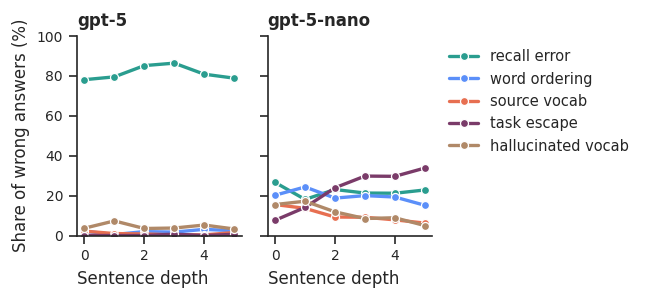

In [6]:
wordorder_depth_df = family_share(
    wrong_df.loc[wrong_df["exp"].astype(str) == "wordorder"],
    ["fuzzy_model", "depth", "error_family"],
)
plot_families = [
    "licensed_near_miss",
    "pure_reordering",
    "source_leakage",
    "task_escape",
    "unlicensed_or_hallucinated",
]
wordorder_plot_df = wordorder_depth_df.loc[
    wordorder_depth_df["error_family"].isin(plot_families)
].copy()
wordorder_plot_df["share_pct"] = 100 * wordorder_plot_df["share"]
wordorder_plot_df["error_family_label"] = wordorder_plot_df["error_family"].map(family_label)
plot_palette = {family_label(family): FAMILY_PALETTE[family] for family in plot_families}
plot_order = family_label_list(plot_families)

fig, axes = plt.subplots(1, 2, figsize=(aes.COLM_PAPER_WIDTH_IN, 2 * aes.FIG_HEIGHT_SINGLE_ROW_IN), sharey=True)
for ax, model in zip(axes, ["gpt-5", "gpt-5-nano"]):
    subset = wordorder_plot_df.loc[
        wordorder_plot_df["fuzzy_model"].astype(str) == model
    ]
    sns.lineplot(
        data=subset,
        x="depth",
        y="share_pct",
        hue="error_family_label",
        hue_order=plot_order,
        palette=plot_palette,
        marker="o",
        linewidth=2,
        ax=ax,
    )
    ax.set_title(model)
    ax.set_xlabel("Sentence depth")
    ax.set_ylabel("Share of wrong answers (%)")
    ax.set_ylim(0, 100)
    if ax is axes[-1]:
        ax.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

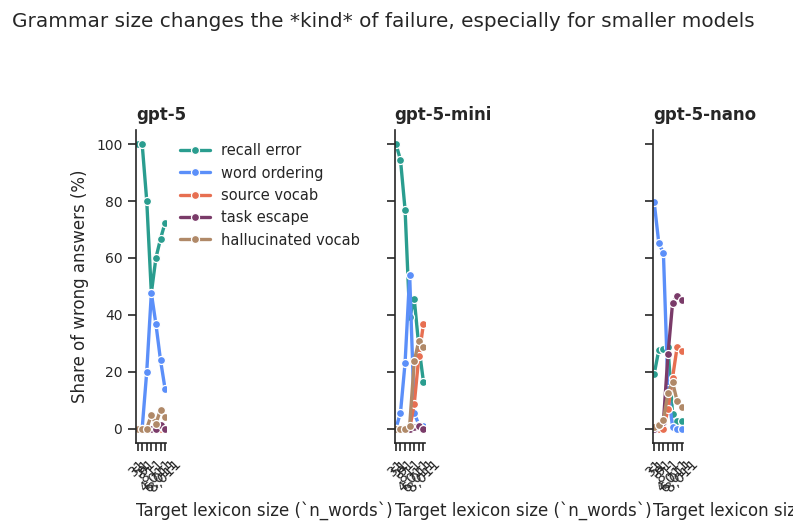

In [7]:
size_family_df = family_share(
    wrong_df.loc[wrong_df["exp"].astype(str) == "size"],
    ["fuzzy_model", "size_bin", "error_family"],
)
plot_families = [
    "licensed_near_miss",
    "pure_reordering",
    "source_leakage",
    "task_escape",
    "unlicensed_or_hallucinated",
]
size_plot_df = size_family_df.loc[
    size_family_df["error_family"].isin(plot_families)
].copy()
size_plot_df["share_pct"] = 100 * size_plot_df["share"]
size_plot_df["error_family_label"] = size_plot_df["error_family"].map(family_label)
plot_palette = {family_label(family): FAMILY_PALETTE[family] for family in plot_families}
plot_order = family_label_list(plot_families)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_THREE_PANEL, sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    subset = size_plot_df.loc[size_plot_df["fuzzy_model"].astype(str) == model]
    if subset.empty:
        ax.set_visible(False)
        continue
    sns.lineplot(
        data=subset,
        x="size_bin",
        y="share_pct",
        hue="error_family_label",
        hue_order=plot_order,
        palette=plot_palette,
        marker="o",
        linewidth=2,
        ax=ax,
    )
    ax.set_title(model)
    ax.set_xlabel("Target lexicon size (`n_words`)")
    ax.set_ylabel("Share of wrong answers (%)")
    ax.tick_params(axis="x", rotation=45)
    if ax is axes[0]:
        ax.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.get_legend().remove()

fig.suptitle(
    "Grammar size changes the *kind* of failure, especially for smaller models", y=1.08
)
plt.tight_layout()
plt.show()


## Agreement: Well-Formed But Wrong

`agreement` is the clearest case where the family view changes the interpretation. The main question here is whether failures are random, or whether the model is producing a target-language sentence with the wrong feature binding.


,fuzzy_model,agreement_condition,rows,exact match,fully licensed within wrong,same-length licensed within wrong,recall error within wrong
0,gpt-5,Agr -> Agr,1680.0,38.4,38.9,23.9,87.1
1,gpt-5,Agr -> NoAgr,1680.0,37.6,43.4,21.8,86.7
2,gpt-5,NoAgr -> Agr,1680.0,23.6,56.4,35.8,84.2
3,gpt-5,NoAgr -> NoAgr,1680.0,89.8,97.7,70.9,97.7
4,gpt-5-mini,Agr -> Agr,1680.0,37.5,30.9,12.5,87.6
5,gpt-5-mini,Agr -> NoAgr,1680.0,37.1,33.6,13.7,88.1
6,gpt-5-mini,NoAgr -> Agr,1680.0,23.6,46.8,28.5,85.3
7,gpt-5-mini,NoAgr -> NoAgr,1680.0,89.2,100.0,70.3,97.8
8,gpt-5-nano,Agr -> Agr,1680.0,25.8,54.2,16.6,77.6
9,gpt-5-nano,Agr -> NoAgr,1680.0,28.2,53.3,12.8,78.0


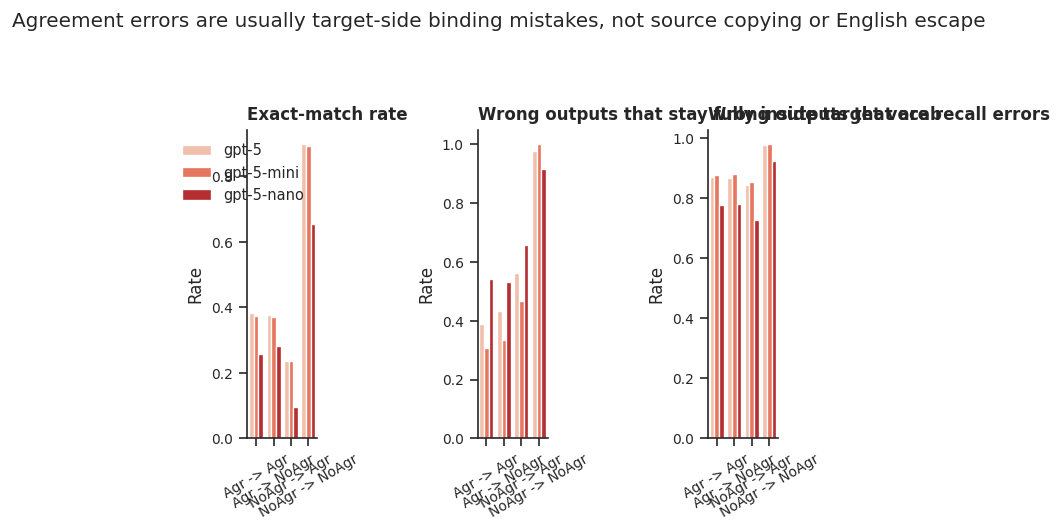

In [8]:
agreement_df = rows_df.loc[rows_df["exp"].astype(str) == "agreement"].copy()
agreement_summary_df = (
    agreement_df.groupby(["fuzzy_model", "agreement_condition"], observed=False)
    .apply(
        lambda group: pd.Series(
            {
                "rows": len(group),
                "exact_match": group["exact_match"].mean(),
                "fully_licensed_within_wrong": group.loc[
                    ~group["exact_match"], "fully_licensed"
                ].mean(),
                "licensed_same_len_within_wrong": (
                    group.loc[~group["exact_match"], "fully_licensed"]
                    & group.loc[~group["exact_match"], "same_len"]
                ).mean(),
                "licensed_near_miss_within_wrong": (
                    group.loc[~group["exact_match"], "error_family"]
                    == "licensed_near_miss"
                ).mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

agreement_display_df = agreement_summary_df.copy()
for col in [
    "exact_match",
    "fully_licensed_within_wrong",
    "licensed_same_len_within_wrong",
    "licensed_near_miss_within_wrong",
]:
    agreement_display_df[col] = (100 * agreement_display_df[col]).round(1)
agreement_display_df = agreement_display_df.rename(
    columns={
        "exact_match": "exact match",
        "fully_licensed_within_wrong": "fully licensed within wrong",
        "licensed_same_len_within_wrong": "same-length licensed within wrong",
        "licensed_near_miss_within_wrong": "recall error within wrong",
    }
)

display(agreement_display_df.sort_values(["fuzzy_model", "agreement_condition"]))

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_THREE_PANEL, sharey=False)
for ax, metric, title in zip(
    axes,
    ["exact_match", "fully_licensed_within_wrong", "licensed_near_miss_within_wrong"],
    [
        "Exact-match rate",
        "Wrong outputs that stay fully inside target vocab",
        "Wrong outputs that are recall errors",
    ],
):
    sns.barplot(
        data=agreement_summary_df,
        x="agreement_condition",
        y=metric,
        hue="fuzzy_model",
        palette=sns.color_palette("Reds", n_colors=3),
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Rate")
    ax.tick_params(axis="x", rotation=30)
    if ax is axes[0]:
        ax.legend(title="", frameon=False, loc="upper right")
    else:
        ax.get_legend().remove()

fig.suptitle(
    "Agreement errors are usually target-side binding mistakes, not source copying or English escape",
    y=1.08,
)
plt.tight_layout()
plt.show()


Interpretation:
- Translating *into* agreement (`NoAgr -> Agr`) is the hardest setting in exact-match terms.
- But even there, many wrong answers are still fully licensed target strings, which suggests a feature-binding problem rather than a total breakdown.
- `NoAgr -> NoAgr` is the easiest condition and also the one where wrong answers are most often fully licensed and same-length.



## Orthography: Script Handling Versus Translation

`orthography` is useful because it cleanly separates lexical/structural translation from writing-system realization. The table and plots below show that the two models fail in qualitatively different ways.


,fuzzy_model,target_orthography,rows,exact match,orthography,task escape,source vocab
0,gpt-5,cyrillic,120.0,45.0,0.0,0.0,0.8
1,gpt-5,latin,120.0,55.0,0.0,0.0,0.0
2,gpt-5,yiddish,120.0,0.0,26.7,1.7,2.5
6,gpt-5-nano,cyrillic,120.0,0.0,59.2,0.8,5.0
7,gpt-5-nano,latin,120.0,0.0,0.0,49.2,15.8
8,gpt-5-nano,yiddish,120.0,0.0,74.2,0.0,13.3


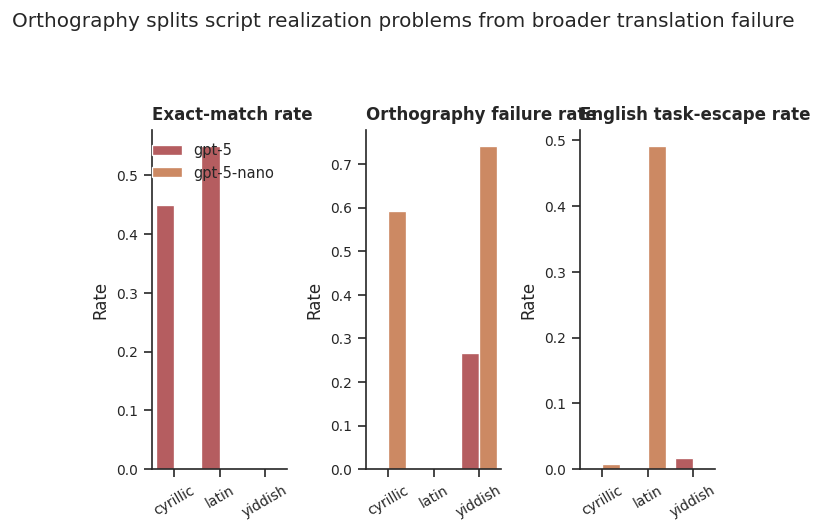

In [9]:
orth_df = rows_df.loc[rows_df["exp"].astype(str) == "orthography"].copy()
orth_summary_df = (
    orth_df.groupby(["fuzzy_model", "target_orthography"], observed=False)
    .apply(
        lambda group: pd.Series(
            {
                "rows": len(group),
                "exact_match": group["exact_match"].mean(),
                "script_or_form": (group["error_family"] == "script_or_form").mean(),
                "task_escape": (group["error_family"] == "task_escape").mean(),
                "source_leakage": (group["error_family"] == "source_leakage").mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

orth_summary_plot_df = orth_summary_df.loc[
    orth_summary_df["fuzzy_model"].astype(str).isin(["gpt-5", "gpt-5-nano"])
].copy()
orth_summary_plot_df["fuzzy_model"] = orth_summary_plot_df["fuzzy_model"].astype(str)
orth_display_df = orth_summary_plot_df.copy()
for col in ["exact_match", "script_or_form", "task_escape", "source_leakage"]:
    orth_display_df[col] = (100 * orth_display_df[col]).round(1)
orth_display_df = orth_display_df.rename(
    columns={
        "exact_match": "exact match",
        "script_or_form": "orthography",
        "task_escape": "task escape",
        "source_leakage": "source vocab",
    }
)

display(orth_display_df.sort_values(["fuzzy_model", "target_orthography"]))

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_THREE_PANEL, sharey=False)
for ax, metric, title in zip(
    axes,
    ["exact_match", "script_or_form", "task_escape"],
    ["Exact-match rate", "Orthography failure rate", "English task-escape rate"],
):
    sns.barplot(
        data=orth_summary_plot_df,
        x="target_orthography",
        y=metric,
        hue="fuzzy_model",
        palette={"gpt-5": "#C44E52", "gpt-5-nano": "#DD8452"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Rate")
    ax.tick_params(axis="x", rotation=30)
    if ax is axes[0]:
        ax.legend(title="", frameon=False, loc="upper right")
    else:
        ax.get_legend().remove()

fig.suptitle(
    "Orthography splits script realization problems from broader translation failure",
    y=1.08,
)
plt.tight_layout()
plt.show()


## Literature Grounding

The taxonomy above is deliberately lightweight, but it tracks familiar distinctions from prior MT and generation work:

- **MQM** frames translation errors as multidimensional quality problems rather than a single scalar score, which is useful here because exact-match collapses near-miss and task-abandonment failures together. See the MQM overview and shared-task framing in [Lommel et al. (2014)](https://aclanthology.org/W14-3302/).
- **Adequacy versus target-side fluency**: [Tu et al. (2017), *Context Gates for Neural Machine Translation*](https://aclanthology.org/Q17-1007/) is a useful reminder that outputs can remain fluent while becoming weakly conditioned on the source. That is close to the `recall error` story here.
- **Hallucination / detachment from the source**: [Guerreiro et al. (2023), *Hallucinations in Neural Machine Translation*](https://aclanthology.org/2023.findings-acl.283/) is relevant for the `task_escape` and `hallucinated vocab` families.
- **Degeneration loops**: [Holtzman et al. (2020), *The Curious Case of Neural Text Degeneration*](https://openreview.net/forum?id=rygGQyrFvH) fits the `degeneration` family.

The distinctive result in this repository is that many failures are **not** classical hallucinations. Especially in `agreement`, the models often produce a target-language sentence that is almost right, but not semantically/feature-wise correct.


In [10]:
EXAMPLE_COLUMNS = [
    "exp",
    "model_name",
    "failure_mode",
    "error_family",
    "depth",
    "n_words",
    "target_recall",
    "licensed_token_share",
    "source_share",
    "input_sentence",
    "output_sentence",
    "model_answer",
]
ENGLISH_EXAMPLE_COLUMNS = EXAMPLE_COLUMNS + ["english_word_tokens"]


def show_examples(family: str, n: int = 3, exp: str | None = None) -> pd.DataFrame:
    subset = wrong_df.loc[wrong_df["error_family"] == family].copy()
    if exp is not None:
        subset = subset.loc[subset["exp"].astype(str) == exp]
    subset = subset.sort_values(
        ["model_name", "exp", "depth", "n_words"], na_position="last"
    )
    subset = subset.head(n)
    display_df = subset[EXAMPLE_COLUMNS].copy()
    display_df["error_family"] = display_df["error_family"].map(family_label)
    for col in ["target_recall", "licensed_token_share", "source_share"]:
        display_df[col] = display_df[col].round(2)
    return display_df


def show_english_examples(
    n_per_family: int = 1, exp: str | None = None
) -> pd.DataFrame:
    subset = wrong_df.loc[wrong_df["contains_english_words"]].copy()
    if exp is not None:
        subset = subset.loc[subset["exp"].astype(str) == exp]
    subset = subset.sort_values(
        [
            "english_word_count",
            "target_recall",
            "model_name",
            "exp",
            "depth",
            "n_words",
        ],
        ascending=[False, False, True, True, True, True],
        na_position="last",
    )
    subset = (
        subset.groupby("error_family", observed=False, as_index=False)
        .head(n_per_family)
        .sort_values(["error_family", "model_name", "exp"], na_position="last")
    )
    display_df = subset[ENGLISH_EXAMPLE_COLUMNS].copy()
    display_df["error_family"] = display_df["error_family"].map(family_label)
    for col in ["target_recall", "licensed_token_share", "source_share"]:
        display_df[col] = display_df[col].round(2)
    return display_df


example_specs = [
    ("licensed_near_miss", "agreement", "Recall error examples (agreement)"),
    ("task_escape", "wordorder", "Task-escape examples (word order)"),
    ("source_leakage", None, "Source-vocab examples"),
    ("script_or_form", "orthography", "Orthography examples"),
    ("truncation_or_omission", None, "Omission examples"),
]

for family, exp, title in example_specs:
    display(Markdown(f"### {title}"))
    display(show_examples(family=family, exp=exp))

display(Markdown("### English-word intrusion examples across families"))
display(show_english_examples())

### Recall error examples (agreement)

,exp,model_name,failure_mode,error_family,depth,n_words,target_recall,licensed_token_share,source_share,input_sentence,output_sentence,model_answer
35761,agreement,gpt-5,same_length_substitution,recall error,0,56.0,0.8,1.0,0.0,numjaz yok baysaywezruy vowdew giy,fejzuldax huctiryeqjol hudnavfidzib fedgaddij fitwadhuq,fejzuldax huctiryeqjol hudnavfidzib fedgaddij fitwad
35762,agreement,gpt-5,same_length_substitution,recall error,0,56.0,0.6,1.0,0.0,rawkartiy qum yiv poywar gomsun,hujvaz jikdiqsir jikpoqfanjol pohcuynok celduxcowhuq,hujvaz jikdiqsir jikpoqfanjol hujvaz celduxcow
35764,agreement,gpt-5,same_length_substitution,recall error,0,56.0,0.8,0.8,0.2,kapsefpobwec xof poywar mahzid,hucmolkug lar dezpacpec pohcuynok luj,hucmolkug lar dezpacpec poywar luj


### Task-escape examples (word order)

,exp,model_name,failure_mode,error_family,depth,n_words,target_recall,licensed_token_share,source_share,input_sentence,output_sentence,model_answer
12187,wordorder,gpt-5,hallucinated_vocab,task escape,3,8008.0,0.55,0.75,0.0,mev ftaw doq uwbibuq pok pmornfur kvewsfus pok gapzsokkuj oyesejij tgozbboyves ay ddiy...,bdolulvoltot tutfid tew lkuhfpucgzil lpiy dnew lkuhfpucgzil fdet keqkbes kbobujpaf tki...,bdolulvoltot UNKNOWN lkuhfpucgzil lpiy dnew lkuhfpucgzil fdet keqkbes kbobujpaf UNKNOW...
12194,wordorder,gpt-5,hallucinated_vocab,task escape,3,8008.0,0.60,0.75,0.0,mev ftaw doq mafdluc pewlfuz pmornfur akem pewlfuz gapzsokkuj exogbgul sfuwifdnib pewl...,bdolulvoltot ir pnix bbac bsamuqik lpiy vukkoluq bsamuqik fdet keqkbes ttihitsoj toztp...,bdolulvoltot unknown bsamuqik lpiy vukkoluq bsamuqik fdet keqkbes unknown toztpin bsam...
11870,wordorder,gpt-5,hallucinated_vocab,task escape,5,6008.0,0.81,0.90,0.0,mzul sof powmbes iszup zadid ag botbgej sirldas edkuder goc us eymilziz mzul sof powmb...,pukpopuw onuf kow ucex al am ksotlziyakgov izew gkif of nfihstih pukpopuw tfog knonbbu...,pukpopuw onuf kow ucex al am ksotlziyakgov izew bozbbiwic nfihstih pukpopuw UNKNOWN nf...


### Source-vocab examples

...

,exp,model_name,failure_mode,error_family,depth,n_words,target_recall,licensed_token_share,source_share,input_sentence,output_sentence,model_answer
7080,orthography,gpt-5,diacritic_drop,orthography,0,6011.0,0.20,0.20,0.0,voymayxevnujcan voqlihxuq peptarpelhupguhzabmel,פױּּאחקַפ לױקצאװּארצָז הִק שאג כײמִֿת,פױאחקפ לױקצאװארצז הק שאג כײמת
7081,orthography,gpt-5,diacritic_drop,orthography,0,6011.0,0.33,0.33,0.0,lexwehqawvon hoqkek cur qenqenmixfirvid kum wokfab,ֿײּצײכ לײבדָש נעצ שאכזײמ צַבלָזצײז פָלמָּלײקתאק,ײצײכ לײבדש נעצ שאכזײמ צבלזצײז פלמלײקתאק
7083,orthography,gpt-5,diacritic_drop,orthography,0,6011.0,0.00,0.00,0.0,nuv quxzew moqxijhib qenqenmixfirvid kum merjotqax,ֿײּצײכ לײבדָש גינװאפװײקנאטיַג שּטהִפצָט ראכּױגטױרטײח,ײצײכ לײבדש גינװאפװײקנאטיג שטהפצט ראכױגטױרטײח


### Omission examples

,exp,model_name,failure_mode,error_family,depth,n_words,target_recall,licensed_token_share,source_share,input_sentence,output_sentence,model_answer
11054,wordorder,gpt-5,partial_span,omission,0,88.0,0.80,1.0,0.0,bpulidpab tav tkefvfixkaw vefvesem ewip,is bulkej optoy fin uvdkoj,bulkej optoy fin uvdkoj
11649,wordorder,gpt-5,hallucinated_vocab,omission,0,4008.0,0.71,1.0,0.0,ey gicsib bgul ppasvtuxag mpok at luskislpuw,otux sum zdiwefic azdguj mov et sgos,otux sum zdiwefic azdguj tal sgos
13206,wordorder,gpt-5,mixed_other,omission,0,4008.0,0.75,1.0,0.0,tehempal utzosoj pow kizztas gecpey tehempal tpeliskonfuj ug,zih anpses bpeh zih tiz evvkijfil seb bsog,zih anpses bpeh zih tiz zsazfdah bsog


### English-word intrusion examples across families

,exp,model_name,failure_mode,error_family,depth,n_words,target_recall,licensed_token_share,source_share,input_sentence,output_sentence,model_answer,english_word_tokens
18596,wordorder,gpt-5-mini,repetition_loop,degeneration,5,6008.0,0.00,0.00,0.00,fkoh kofsnendtunem ogankmoh ppaptlek ksez elip ejevgub ob uz fbam ejevgub ob gsoluvot ...,gibzaboger gman puptav ot upgijpfohup duzvpav gonsahtfun duzvpav ptal puptav ot gibzab...,TRANSLATION_NOT_POSSIBLE,"[translation, not, possible]"
12227,wordorder,gpt-5,hallucinated_vocab,recall error,5,8008.0,0.71,0.89,0.00,kmif nmub piqtvav pok mev ftaw doq et pok lig tenam pok dobtkusffufdib kkuw pok pmornf...,ltubsayfpov psok lkuhfpucgzil bdolulvoltot ksil lkuhfpucgzil ij at lkuhfpucgzil gewkos...,ltubsayfpov psok lkuhfpucgzil bdolulvoltot poj lkuhfpucgzil ij at lkuhfpucgzil UNKNOWN...,"[unknown, name, np]"
20512,wordorder,gpt-5-mini,hallucinated_vocab,other,5,8008.0,0.48,0.87,0.09,denid nigvzav ap zzajom psom gbispgaxik fin pol kgaw dtay iq ukmbetzufboh anej iq uveg...,gujsuquhaf kuvmecszustaf kuvmecszustaf kuvmecszustaf gujsuquhaf kahgbemog fkegsset ahf...,dtukurten itzzuq tehaz os kahgbemog iv dzid dd en baqmdojas dzid gsocdpuw sab dzid kah...,"[dd, bin]"
6644,orthography,gpt-5-nano,wrong_script,orthography,4,6011.0,0.00,0.00,0.06,homkep hovcagcen niqsum yuddufzevkakbol vexlebyarboyvulzog niqsum zud letqadtiw paqtej...,дишпицфёщ дишпицфёщ дишпицфёщ субдэжсэт нём хищкёч пэвфоглижбар хирпов хын вех дэбщющ ...,Im sorry but I cant provide a reliable translation for this sentence using the given S...,"[im, sorry, but, cant, provide, reliable, translation, for, this, sentence, using, the..."
6656,orthography,gpt-5-nano,copied_source,source vocab,5,6011.0,0.00,0.00,1.00,fahpazwub taxcekpeysis yussunsoscaq hebvedwunmarvex janbez six der qokyux niqsum bublo...,субдэжсэт нём дишпицфёщ субдэжсэт нём субдэжсэт нём дишпицфёщ маррирпёлзуш кюсшемгяпру...,fahpazwub taxcekpeysis yussunsoscaq hebvedwunmarvex janbez six der qokyux niqsum bublo...,"[six, der, sec]"
4318,size,gpt-5-nano,too_long,task escape,5,4011.0,0.00,0.00,0.04,jobtobhed guyjefnoxtoqfej honkaybagmer kog jaqteq cum zatcin honkaybagmer xinxemdok ju...,tovdevduq zudguyjoq tekmegyoygoz zudguyjoq rebyejfizheh zudguyjoq huwdigcewwif niproxk...,Im sorry but I cant reliably translate this sentence with the given SCFG The grammar i...,"[im, sorry, but, cant, translate, this, sentence, with, the, given, grammar, is, extre..."
8870,wordorder,gpt-5-nano,too_short,omission,5,8008.0,0.05,0.25,0.00,pmornfur pduxbmuv pewlfuz mev ftaw doq nac pewlfuz pmornfur pkoz pok otarsbapvej tictu...,lpiy uc unvtow bsamuqik bdolulvoltot kgelpgiq bsamuqik lpiy btoh in lkuhfpucgzil gkihu...,the man saw the girl in the garden,"[the, man, girl, garden]"
8421,wordorder,gpt-5-nano,hallucinated_vocab,hallucinated vocab,1,6008.0,0.00,0.00,0.00,mzul sof powmbes vbatftah ul pnojad ggoh sirldas don spazah lib don vilmgiqpzor,pukpopuw bmec del ptix ksotlziyakgov fejdtif gorttaxttut fepkecer fejdtif tkoq,The quick brown fox jumps over the lazy dog,"[the, quick, brown, fox, jumps, over, lazy, dog]"


## Takeaways

- The most important correction to the first-pass story is that many errors are **target-language recall errors**, not generic hallucinations. This is strongest in `agreement`, where wrong outputs often stay fully inside the target lexicon.
- Difficulty changes the *kind* of error. Stronger models tend to degrade gracefully into recall errors or word ordering mistakes; weaker models increasingly leak source vocab or answer in English about the task.
- English lexical intrusion is broader than `task_escape`: some failures are explicit English refusals, while others are straight English translations or mixed English-target outputs.
- `orthography` is genuinely special: it reveals a separate axis of failure around script and diacritic realization, which would be easy to misread as ordinary lexical error if we only looked at exact match.
- For follow-up work, the most promising next step is to distinguish **lexical substitution**, **feature-binding**, and **scope/attachment** errors inside the large `recall error` bucket, especially for `agreement`.